## **Fatah Wiksa Adristo JCDSPMJKT-36-006 | Capstsone Project Module 2 | AWS SaaS Sales**

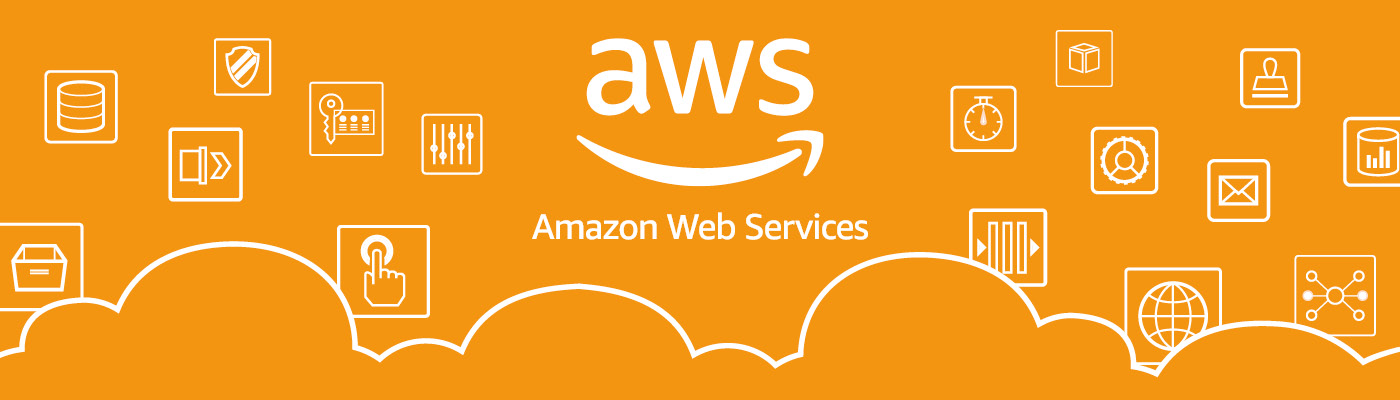

## **AWS SaaS Sales and Performance Analysis: A Regional Analysis of Profitability and Strategic Market**

# **Background**
Amazon Web Services (AWS) is a subsidiary of the company Amazon that provides their users with cloud computing platforms and APIs which allows large scale data operations. AWS provides the utility of the internet that allows businesses to pay as much as they use enabling massive scale operations without building their own data centers.

# **Business Problem Statements**
From the data AWS has been collecting as a software company, the insights needed will be the following:
1. **Analyze the company's sales and profit performance between regions**. Identify which regions out of the three that needs more attention.
2. **Analyze the region's cities and industries**. Identify which cities are struggling and what industry is the most dominant in that area.
3. **Compare that city's performance to another city with a better performance**. Identify another city with better sales and profit performance and find the reason why it's performing better.

The company wants to find the place where the profit generated is negative and try to fix the issue.

# **Objectives**
The goal of this analysis is to see if we can find a solution to the low or negative profit of a region, starting from its lowest performing city. 

## **Data**
This dataset contains the records of SaaS transactions from AWS to other companies. The dataset could be found [here](https://www.kaggle.com/datasets/nnthanh101/aws-saas-sales).

In [2]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind, kstest
from tabulate import tabulate

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_column', 0)

This dataset consists of SaaS software sales made by AWS. This dataset consists of 19 columns that functions as:
- Row ID: Unique ID of every row
- Order ID: Unique ID for every order
- Order Date: The date in which the order was made
- Date Key: Numerical representation of the order date (YYYYMMDD)
- Contact Name: The person who made the order
- Country: Country where the person who ordered is from
- City: City where the person who ordered is from
- Region: Region where the person who ordered is from
- Subregion: Subregion where the person who ordered is from
- Customer: The company who ordered
- Customer ID: Unique ID for every customer
- Industry: Industry where the customer belongs to
- Segment: Segment where the customer belongs to
- Product: Product sold
- License: License code for the product sold
- Sales: Total sales from the transaction
- Quantity: Amount of purchase from the transaction
- Discount: Discount given from every transaction
- Profit: Profit gained from transaction

Below is a peek on the data.

In [3]:
df=pd.read_csv("SaaS-Sales.csv")
df.sample(n=5)

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
1381,1382,APJ-2022-100566,9/4/2022,20220904,Warren McGrath,Australia,Melbourne,APJ,ANZ,Huawei,1086,Tech,Enterprise,SaaS Connector Pack,E6KBMU5BWM,83.952,3,0.6,-90.2484
2495,2496,APJ-2020-136644,6/16/2020,20200616,Jake Mackenzie,India,Bangalore,APJ,IND,Glencore,1083,Misc,SMB,FinanceHub,UJN638SJFL,647.840,8,0.0,32.3920
1307,1308,AMER-2022-141397,6/21/2022,20220621,Lucas Mathis,United States,Newark,AMER,NAMER,Lowes,1060,Retail,SMB,ContactMatcher,OP3VIG8Z1W,17.712,3,0.2,6.4206
9934,9935,EMEA-2022-114405,4/8/2022,20220408,Diane Buckland,France,Paris,EMEA,EU-WEST,Ford Motor,1009,Manufacturing,SMB,OneView,6FHG6A9OEM,33.528,3,0.2,2.5146
4070,4071,APJ-2022-145303,8/29/2022,20220829,Steven Rees,Japan,Aichi,APJ,JAPN,Siemens,1043,Manufacturing,SMB,ContactMatcher,F0S0QOHZP6,10.024,4,0.8,-16.5396


## **Data Understanding & Cleaning**
Before the data is ready, the data must be cleaned and understood so the analysis process Before data can be analyzed, the dataset needs to be better understood. This stage is called data understanding. At this stage, the number of anomalies, such as duplicate data and missing data, and the type of data to be processed are identified.

After further understanding the dataset, data cleaning is performed, which removes anomalous data and changes the data type to a type appropriate for the analysis. This step is carried out to ensure that the analysis results are not biased by anomalous data.

In [4]:
# Display each column statistic descriptive
display(df.describe(), df.describe(include='object'))

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit
count,9994.000000,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2.021803e+07,1049.771963,229.858001,3.789574,0.156203,28.656896
std,2885.163629,1.123898e+04,29.719388,623.245101,2.225110,0.206452,234.260108
min,1.000000,2.020010e+07,1001.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.976000


,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,793,48,262,3,12,99,10,3,14,9994
top,EMEA-2023-100111,9/6/2022,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,16GRM07R1K
freq,14,38,37,2001,922,4219,2507,192,2127,5191,1842,1


In [5]:
# Show amount of rows and columns
df.shape

# Shows amount of columns, non null data, and its type
df.info()

# Amount of null values
print('Missing values status:', df.isnull().values.any())
missing_values = pd.DataFrame(df.isnull().sum(), columns=['Total Null Values'])
missing_values['Percentage'] = (missing_values['Total Null Values'] / df.shape[0]) * 100
missing_values.sort_values(by='Percentage', ascending=False).reset_index()

# Amount of duplicates
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

np.int64(0)

From the information given:
- Dataset has 9994 rows and 19 columns
- No null data
- No duplicate data
- Order date type needs to be changed to datetime
- Customer ID and Row ID still in integer, needs to be changed to string

In [6]:
# Change Order Date to datetime
df = pd.read_csv('SaaS-Sales.csv', parse_dates=['Order Date'], dtype= {'Customer ID': str})

# Drop Row ID and Date Key because Date Key is same as Order Date
df = df.drop(columns=['Date Key'])


df.head(5)

,Row ID,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,2022-11-09,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,2022-06-13,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,2021-10-11,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


## **Check Unique Values for Every Column**

In [7]:
pd.set_option('display.max_colwidth', 0)
# Display unique data for every column
list_item = []
for col in df.columns :
    list_item.append( [col, df[col].nunique(), df[col].unique()])

unique_table = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=list_item)
unique_table

,Column Name,Number of Unique,Unique Sample
0,Row ID,9994,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, ...]"
1,Order ID,5009,"[EMEA-2022-152156, AMER-2022-138688, EMEA-2021-108966, AMER-2020-115812, EMEA-2023-114412, AMER-2022-161389, APJ-2021-118983, EMEA-2020-105893, EMEA-2020-167164, AMER-2020-143336, AMER-2022-137330, EMEA-2023-156909, EMEA-2021-106320, AMER-2022-121755, EMEA-2021-150630, APJ-2023-107727, APJ-2022-117590, APJ-2021-117415, APJ-2023-120999, AMER-2022-101343, EMEA-2023-139619, EMEA-2022-118255, AMER-2020-146703, APJ-2022-169194, APJ-2021-115742, EMEA-2022-105816, EMEA-2022-111682, AMER-2021-135545, APJ-2021-164175, AMER-2020-106376, EMEA-2022-119823, EMEA-2022-106075, AMER-2023-114440, EMEA-2021-134026, APJ-2023-118038, APJ-2020-147606, EMEA-2022-127208, AMER-2020-139451, EMEA-2021-149734, APJ-2023-119662, AMER-2023-140088, EMEA-2023-155558, APJ-2022-159695, AMER-2022-109806, EMEA-2021-149587, EMEA-2023-109484, EMEA-2023-161018, AMER-2023-157833, EMEA-2022-149223, APJ-2022-158568, EMEA-2022-129903, EMEA-2021-156867, EMEA-2023-119004, APJ-2021-129476, EMEA-2023-146780, EMEA-2022-128867, AMER-2020-115259, AMER-2021-110457, EMEA-2021-136476, APJ-2022-103730, APJ-2020-152030, APJ-2020-134614, AMER-2023-107272, AMER-2022-125969, AMER-2023-164147, AMER-2022-145583, EMEA-2022-110366, AMER-2023-106180, EMEA-2023-155376, AMER-2021-110744, AMER-2020-110072, EMEA-2022-114489, AMER-2022-158834, AMER-2021-124919, AMER-2021-118948, AMER-2020-104269, APJ-2022-114104, AMER-2022-162733, EMEA-2021-119697, APJ-2022-154508, AMER-2022-113817, APJ-2020-139892, AMER-2020-118962, APJ-2020-100853, APJ-2023-152366, AMER-2021-101511, EMEA-2021-137225, APJ-2020-166191, EMEA-2020-158274, EMEA-2022-105018, AMER-2020-123260, APJ-2022-157000, EMEA-2021-102281, AMER-2021-131457, AMER-2020-140004, AMER-2023-107720, EMEA-2023-124303, AMER-2023-105074, EMEA-2020-133690, APJ-2023-116701, ...]"
2,Order Date,1237,"[2022-11-09 00:00:00, 2022-06-13 00:00:00, 2021-10-11 00:00:00, 2020-06-09 00:00:00, 2023-04-16 00:00:00, 2022-12-06 00:00:00, 2021-11-22 00:00:00, 2020-11-11 00:00:00, 2020-05-13 00:00:00, 2020-08-27 00:00:00, 2022-12-10 00:00:00, 2023-07-17 00:00:00, 2021-09-25 00:00:00, 2022-01-16 00:00:00, 2021-09-17 00:00:00, 2023-10-20 00:00:00, 2022-12-09 00:00:00, 2021-12-27 00:00:00, 2023-09-11 00:00:00, 2022-07-18 00:00:00, 2023-09-20 00:00:00, 2022-03-12 00:00:00, 2020-10-20 00:00:00, 2022-06-21 00:00:00, 2021-04-18 00:00:00, 2022-12-12 00:00:00, 2022-06-18 00:00:00, 2021-11-24 00:00:00, 2021-04-30 00:00:00, 2020-12-05 00:00:00, 2022-06-05 00:00:00, 2022-09-19 00:00:00, 2023-09-15 00:00:00, 2021-04-26 00:00:00, 2023-12-10 00:00:00, 2020-11-26 00:00:00, 2020-10-12 00:00:00, 2021-09-03 00:00:00, 2023-11-14 00:00:00, 2023-05-29 00:00:00, 2023-10-27 00:00:00, 2022-04-06 00:00:00, 2022-09-18 00:00:00, 2021-01-31 00:00:00, 2023-11-07 00:00:00, 2023-11-10 00:00:00, 2023-06-18 00:00:00, 2022-09-07 00:00:00, 2022-08-30 00:00:00, 2022-12-02 00:00:00, 2021-11-13 00:00:00, 2023-11-24 00:00:00, 2021-10-15 00:00:00, 2023-12-26 00:00:00, 2022-11-04 00:00:00, 2020-08-25 00:00:00, 2021-03-02 00:00:00, 2021-04-05 00:00:00, 2020-12-26 00:00:00, 2020-09-20 00:00:00, 2023-11-06 00:00:00, 2022-11-07 00:00:00, 2023-02-03 00:00:00, 2022-10-14 00:00:00, 2022-09-06 00:00:00, 2023-09-19 00:00:00, 2023-12-23 00:00:00, 2021-09-07 00:00:00, 2020-10-22 00:00:00, 2022-03-14 00:00:00, 2021-05-31 00:00:00, 2021-05-28 00:00:00, 2020-03-01 00:00:00, 2022-11-21 00:00:00, 2022-05-12 00:00:00, 2021-12-28 00:00:00, 2022-11-17 00:00:00, 2022-11-08 00:00:00, 2020-09-08 00:00:00, 2020-08-05 00:00:00, 2020-09-14 00:00:00, 2023-04-22 00:00:00, 2

Looking through the unique values for every column. Everything seems in order and nothing needs to change.

## **Check Spelling and Locations for Cities and Countries**

In [8]:
# Display unique countries for every region
df.groupby('Region')['Country'].unique().reset_index()

# Display names of cities for every country
df.groupby('Country')['City'].unique().reset_index()

,Country,City
0,Argentina,"[Córdoba, Buenos Aires, Mendoza, Rosario]"
1,Australia,"[Wollongong, Sydney, Canberra, Geelong, Melbourne, Adelaide, Brisbane, Hobart, Gold Coast, Perth]"
2,Austria,[Vienna]
3,Belgium,"[Brussels, Antwerp, Ghent]"
4,Brazil,"[Salvador, Rio de Janeiro, São Paulo, Manaus, Belo Horizonte, Brasília]"
5,Canada,"[Toronto, Vancouver, Hamilton, Ottawa, Montreal, Calgary, Quebec, Regina, Winnipeg, Victoria]"
6,Chile,"[Puente Alto, Santiago, Antofagasta]"
7,China,"[Shanghai, Shenzhen, Guangzhou, Beijing, Tianjin, Suzhou, Chengdu]"
8,Colombia,"[Bogotá, Medellín, Cali]"
9,Costa Rica,[San José]


The spelling seems to be in order and the cities belong to their respective countries. Nothing needs to be changed.

## **Check Spelling For Products, Industries, and Segments**

In [9]:
# Display names of Products, Industries, and Segments
df.groupby('Industry')['Product'].unique().reset_index()

,Industry,Product
0,Communications,"[ChatBot Plugin, Marketing Suite - Gold, OneView, Data Smasher, ContactMatcher, Support, Big Ol Database, SaaS Connector Pack, SaaS Connector Pack - Gold, FinanceHub, Site Analytics, Storage, Marketing Suite]"
1,Consumer Products,"[ContactMatcher, Site Analytics, SaaS Connector Pack, Data Smasher, Support, OneView, SaaS Connector Pack - Gold, ChatBot Plugin, FinanceHub, Marketing Suite, Big Ol Database, Marketing Suite - Gold, Storage, Alchemy]"
2,Energy,"[Marketing Suite, FinanceHub, ContactMatcher, Marketing Suite - Gold, Support, Site Analytics, OneView, Storage, SaaS Connector Pack, Big Ol Database, ChatBot Plugin, Data Smasher, Alchemy, SaaS Connector Pack - Gold]"
3,Finance,"[SaaS Connector Pack, ChatBot Plugin, Site Analytics, ContactMatcher, OneView, SaaS Connector Pack - Gold, Marketing Suite, FinanceHub, Marketing Suite - Gold, Data Smasher, Support, Storage, Big Ol Database, Alchemy]"
4,Healthcare,"[OneView, ContactMatcher, FinanceHub, SaaS Connector Pack, Marketing Suite - Gold, SaaS Connector Pack - Gold, Site Analytics, Data Smasher, Support, Storage, Alchemy, ChatBot Plugin, Marketing Suite, Big Ol Database]"
5,Manufacturing,"[Marketing Suite - Gold, ContactMatcher, Data Smasher, FinanceHub, SaaS Connector Pack, Support, OneView, Storage, Marketing Suite, ChatBot Plugin, Site Analytics, Big Ol Database, SaaS Connector Pack - Gold, Alchemy]"
6,Misc,"[Support, OneView, Data Smasher, SaaS Connector Pack, ContactMatcher, SaaS Connector Pack - Gold, ChatBot Plugin, Site Analytics, Marketing Suite - Gold, FinanceHub, Storage, Big Ol Database, Alchemy, Marketing Suite]"
7,Retail,"[Marketing Suite - Gold, ChatBot Plugin, OneView, FinanceHub, Storage, Site Analytics, ContactMatcher, Data Smasher, SaaS Connector Pack, Support, Big Ol Database, SaaS Connector Pack - Gold, Marketing Suite, Alchemy]"
8,Tech,"[ContactMatcher, Marketing Suite, SaaS Connector Pack, SaaS Connector Pack - Gold, ChatBot Plugin, Marketing Suite - Gold, Data Smasher, Support, FinanceHub, Site Analytics, Storage, Big Ol Database, OneView, Alchemy]"
9,Transportation,"[ContactMatcher, SaaS Connector Pack, Marketing Suite - Gold, Data Smasher, FinanceHub, ChatBot Plugin, Site Analytics, Support, Big Ol Database, OneView, Storage, Alchemy, Marketing Suite, SaaS Connector Pack - Gold]"


In [10]:
df.groupby('Segment')['Product'].unique().reset_index()

,Segment,Product
0,Enterprise,"[OneView, ContactMatcher, Support, SaaS Connector Pack - Gold, Marketing Suite, FinanceHub, Site Analytics, Marketing Suite - Gold, SaaS Connector Pack, Data Smasher, ChatBot Plugin, Storage, Big Ol Database, Alchemy]"
1,SMB,"[Marketing Suite, FinanceHub, ContactMatcher, Marketing Suite - Gold, SaaS Connector Pack, ChatBot Plugin, Site Analytics, OneView, Support, Data Smasher, SaaS Connector Pack - Gold, Storage, Big Ol Database, Alchemy]"
2,Strategic,"[FinanceHub, ChatBot Plugin, OneView, Site Analytics, SaaS Connector Pack, Marketing Suite - Gold, Data Smasher, ContactMatcher, Storage, SaaS Connector Pack - Gold, Support, Marketing Suite, Big Ol Database, Alchemy]"


In [11]:
df.groupby('Segment')['Industry'].unique().reset_index()

,Segment,Industry
0,Enterprise,"[Healthcare, Misc, Finance, Energy, Retail, Manufacturing, Consumer Products, Transportation, Tech, Communications]"
1,SMB,"[Energy, Finance, Tech, Manufacturing, Retail, Consumer Products, Healthcare, Communications, Transportation, Misc]"
2,Strategic,"[Energy, Retail, Consumer Products, Manufacturing, Tech, Finance, Transportation, Healthcare, Communications, Misc]"


Spelling on the data above seems right. No change needed.

## **Check Anomalies on Sales, Discount, and Quantity**

In [12]:
# Sales
minSales = df['Sales'].min()
maxSales = df['Sales'].max()

salesInfo = pd.DataFrame({'Lowest Sales': [minSales], 'Highest Sales': [maxSales]})
salesInfo['Lowest Sales'] = salesInfo['Lowest Sales'].apply(lambda x: f'${x:,.2f}')
salesInfo['Highest Sales'] = salesInfo['Highest Sales'].apply(lambda x: f'${x:,.2f}')

display(salesInfo)

,Lowest Sales,Highest Sales
0,$0.44,"$22,638.48"


In [13]:
# Discount
minDiscount = df['Discount'].min() * 100
maxDiscount = df['Discount'].max() * 100

discountInfo = pd.DataFrame({'Lowest discount': [minDiscount], 'Highest discount': [maxDiscount]})
discountInfo['Lowest discount'] = discountInfo['Lowest discount'].round(2).astype(str) + '%'
discountInfo['Highest discount'] = discountInfo['Highest discount'].round(2).astype(str) + '%'

display(discountInfo)

,Lowest discount,Highest discount
0,0.0%,80.0%


In [14]:
# Quantity
minQuantity = df['Quantity'].min() 
maxQuantity = df['Quantity'].max() 

quantityInfo = pd.DataFrame({'Lowest Quantity': [minQuantity], 'Highest Quantity': [maxQuantity]})
quantityInfo['Highest Quantity'] = quantityInfo['Highest Quantity'].astype(int).astype(str) + ' pcs'
quantityInfo['Lowest Quantity'] = quantityInfo['Lowest Quantity'].astype(int).astype(str) + ' pcs'

display(quantityInfo)

,Lowest Quantity,Highest Quantity
0,1 pcs,14 pcs


Everything seems in order and nothing needs to be changed.

## **Check for Whitespace**

In [15]:
import re

In [16]:
def check_excessive_whitespace(value):
    if isinstance(value, str):
        return bool(re.search(r'\s{2,}', value))  
    return False
    
whitespace_info = []
for column in df.columns:
    has_excessive_whitespace = df[column].apply(check_excessive_whitespace).any()
    whitespace_info.append({'Column': column, 'Has Excessive Whitespace': has_excessive_whitespace})

whitespace_df = pd.DataFrame(whitespace_info)
whitespace_df

,Column,Has Excessive Whitespace
0,Row ID,False
1,Order ID,False
2,Order Date,False
3,Contact Name,False
4,Country,False
5,City,False
6,Region,False
7,Subregion,False
8,Customer,False
9,Customer ID,False


No white space found in the data.

## **Check for Missing and Duplicate Values**

In [17]:
print('Missing values status:', df.isnull().values.any())
missing_values = pd.DataFrame(df.isnull().sum(), columns=['Total Null Values'])
missing_values['Percentage'] = (missing_values['Total Null Values'] / df.shape[0]) * 100
missing_values.sort_values(by='Percentage', ascending=False).reset_index()

Missing values status: False


,index,Total Null Values,Percentage
0,Row ID,0,0.0
1,Order ID,0,0.0
2,Discount,0,0.0
3,Quantity,0,0.0
4,Sales,0,0.0
5,License,0,0.0
6,Product,0,0.0
7,Segment,0,0.0
8,Industry,0,0.0
9,Customer ID,0,0.0


In [18]:
df.duplicated().sum()

np.int64(0)

The dataset has no missing values nor duplicated data as seen earlier in data understanding.

## **Data Visualization and Analysis**
In this phase, the data will be visualized which will make it easier to be analyzed.

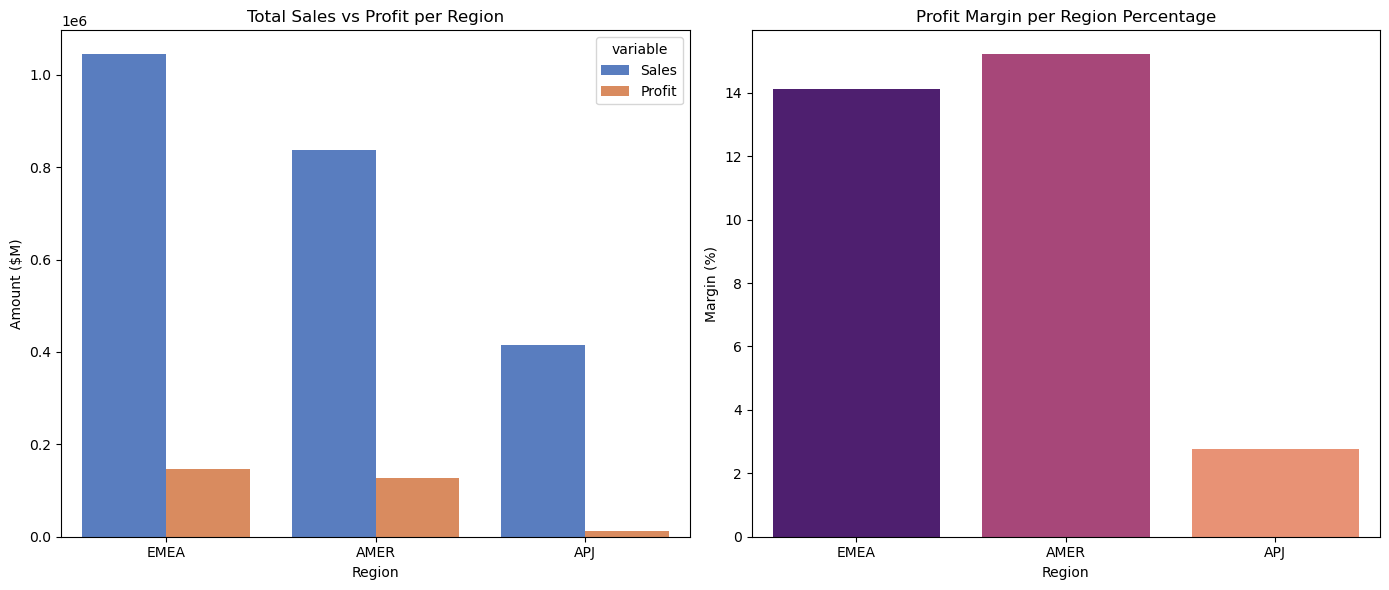

In [19]:
# Aggregate profit and sales for every region
region_perf = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Profit', ascending=False).reset_index()

# Profit argin per region (%)
region_perf['Margin (%)'] = (region_perf['Profit'] / region_perf['Sales']) * 100

# Visualization
plt.figure(figsize=(14, 6))

# Sales vs Profit for every region
plt.subplot(1, 2, 1)
region_melted = region_perf.melt(id_vars='Region', value_vars=['Sales', 'Profit'])
sns.barplot(data=region_melted, x='Region', y='value', hue='variable', palette='muted')
plt.title('Total Sales vs Profit per Region')
plt.ylabel('Amount ($M)')

# Profit margin per region
plt.subplot(1, 2, 2)
sns.barplot(data=region_perf, x='Region', y='Margin (%)', palette='magma')
plt.title('Profit Margin per Region Percentage')
plt.ylabel('Margin (%)')

plt.tight_layout()
plt.show()

Here, we see that the APJ region has the lowest sales, profit, and profit margin out of all the regions. We don't know why for now, but we are going to display the cities in APJ and their sales profit. We will also show the industry split in APJ to find out what the most dominant industry is in this region.

## **APJ Cities Comparison**

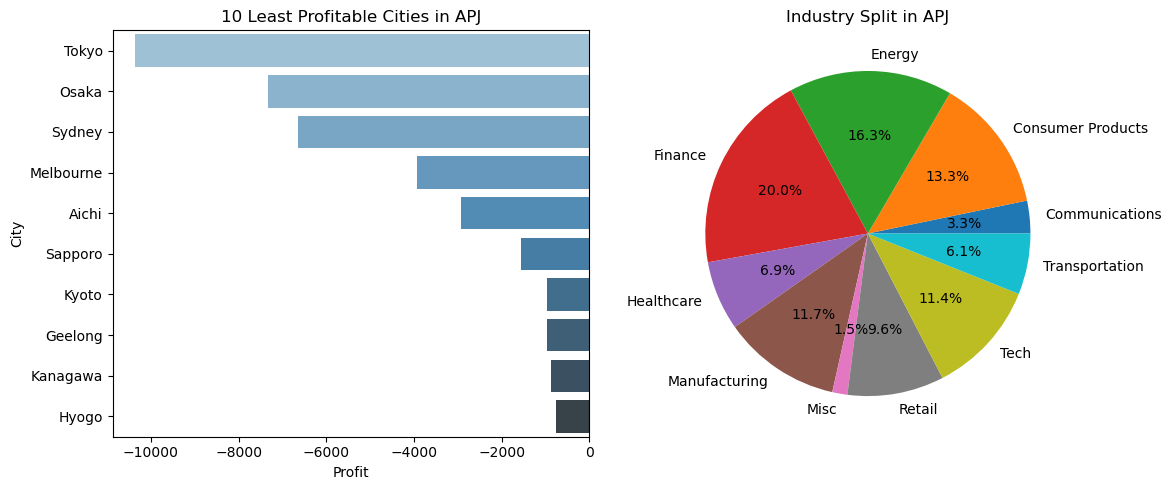

In [20]:
# Filter APJ data
apj_df = df[df['Region'] == 'APJ']

# Sales analysis per subregion
apj_subregion = apj_df.groupby('Subregion')['Sales'].sum().sort_values(ascending=False).reset_index()

# 10 least profitable cities in APJ
apj_city_profit = apj_df.groupby('City')['Profit'].sum().nsmallest(10).reset_index()
plt.figure(figsize=(12, 5))

# Plot for least profitable cities
plt.subplot(1, 2, 1)
sns.barplot(data=apj_city_profit, x='Profit', y='City', palette='Blues_d')
plt.title('10 Least Profitable Cities in APJ')

# Plot dominant industry APJ
plt.subplot(1, 2, 2)
apj_industry = apj_df.groupby('Industry')['Sales'].sum().reset_index()
plt.pie(apj_industry['Sales'], labels=apj_industry['Industry'], autopct='%1.1f%%')
plt.title('Industry Split in APJ')

plt.tight_layout()
plt.show()

It looks like Tokyo is the least profitable city in APJ and Finance leads the industry in APJ. We still don't know why that is, which is why we will continue to display the industries, products, and discounts sold and given in Tokyo.

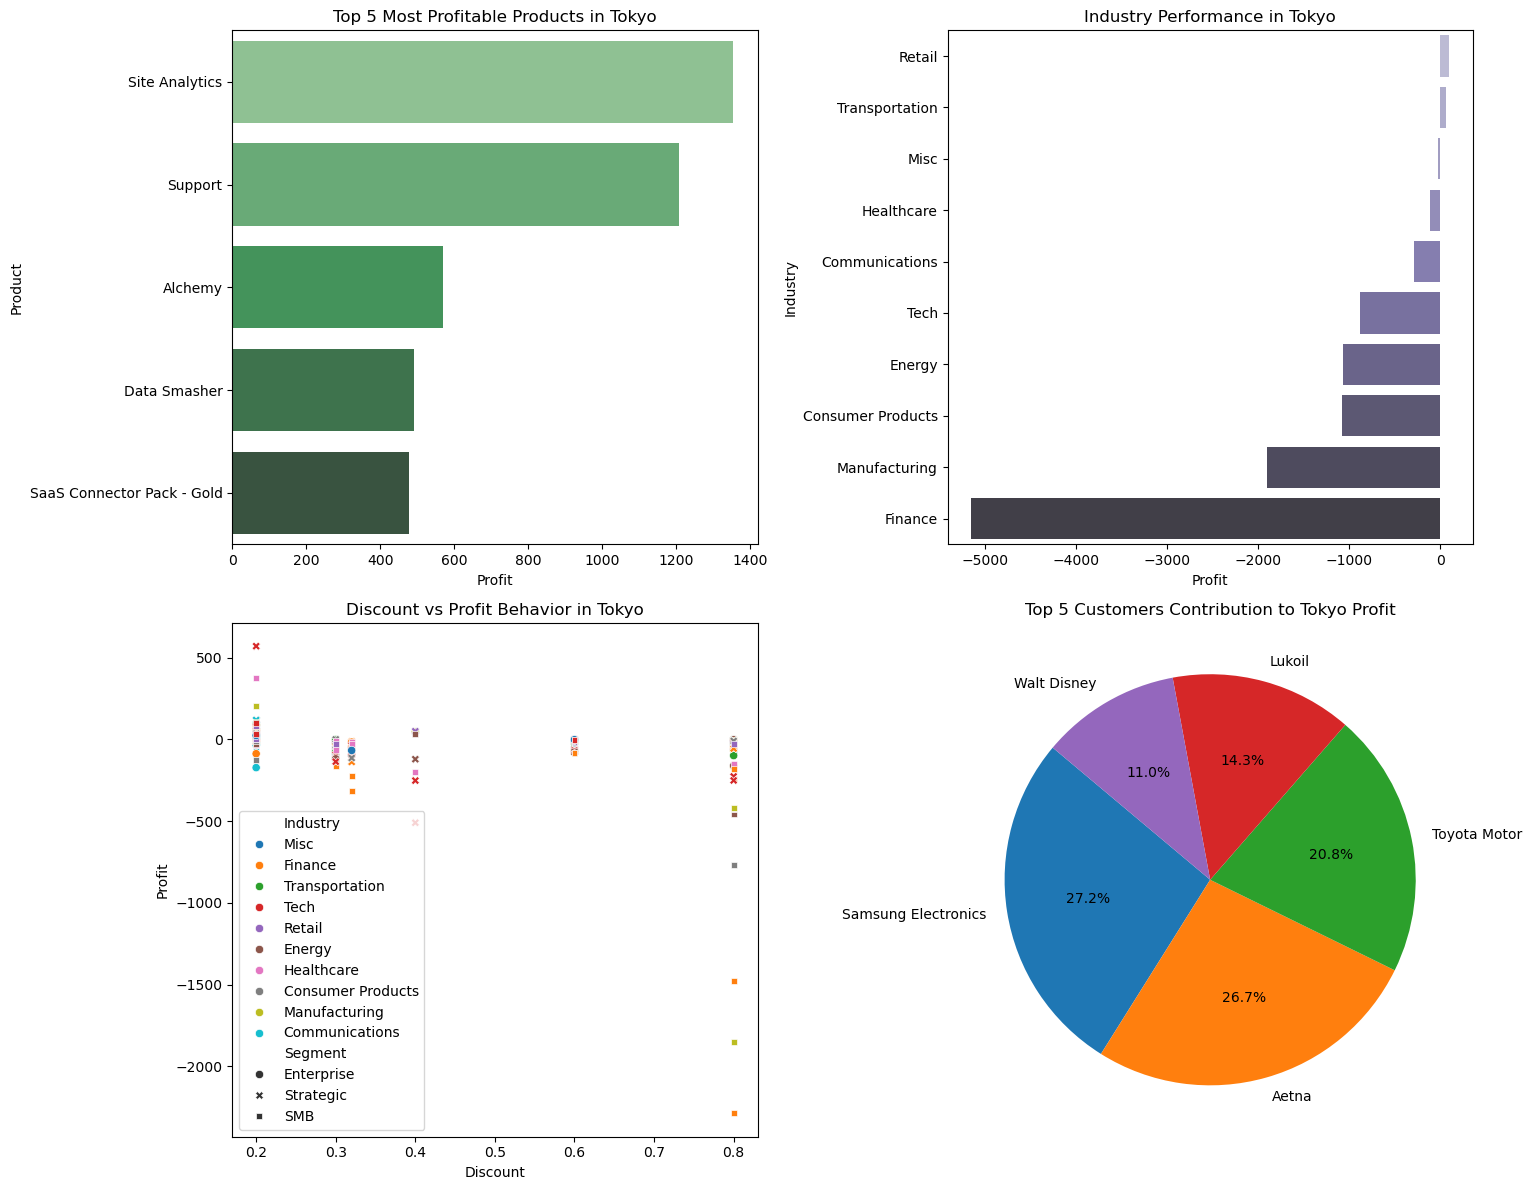

In [21]:
# Tokyo filter
tokyo_df = df[df['City'] == 'Tokyo'].copy()

# Best products in Tokyo
tokyo_products = tokyo_df.groupby('Product').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values(by='Profit', ascending=False).reset_index()

# Tokyo industry analysis
tokyo_industries = tokyo_df.groupby('Industry').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Profit', ascending=False).reset_index()

# --- Visualization ---
plt.figure(figsize=(15, 12))

# Tokyo profit per product
plt.subplot(2, 2, 1)
sns.barplot(data=tokyo_products.head(5), x='Profit', y='Product', palette='Greens_d')
plt.title('Top 5 Most Profitable Products in Tokyo')

# Tokyo profit per industry
plt.subplot(2, 2, 2)
sns.barplot(data=tokyo_industries, x='Profit', y='Industry', palette='Purples_d')
plt.title('Industry Performance in Tokyo')

# Discount vs profit correlation Tokyo
plt.subplot(2, 2, 3)
sns.scatterplot(data=tokyo_df, x='Discount', y='Profit', hue='Industry', style='Segment')
plt.title('Discount vs Profit Behavior in Tokyo')

# Top customer general Tokyo
tokyo_customers = tokyo_df.groupby('Customer')['Profit'].sum().nlargest(5).reset_index()
plt.subplot(2, 2, 4)
plt.pie(tokyo_customers['Profit'], labels=tokyo_customers['Customer'], autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Customers Contribution to Tokyo Profit')

plt.tight_layout()
plt.show()

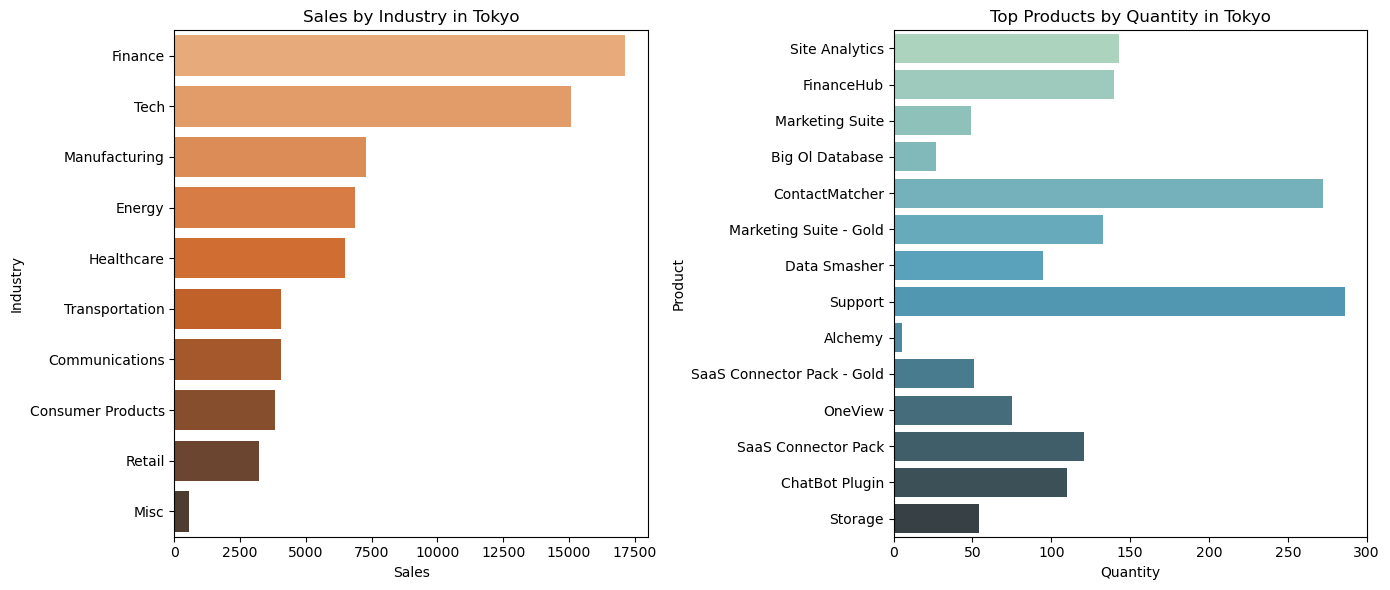

In [22]:
# Tokyo Filter 
tokyo_df = df[df['City'] == 'Tokyo'].copy()

# Tokyo industry analysis
tokyo_industry = tokyo_df.groupby('Industry').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values(by='Sales', ascending=False).reset_index()

# Tokyo product analysis
tokyo_products = tokyo_df.groupby('Product').agg({
    'Sales': 'sum',
    'Quantity': 'sum'
}).sort_values(by='Sales', ascending=False).reset_index()

# --- Visualization ---
plt.figure(figsize=(14, 6))

# Sales per industry Tokyo
plt.subplot(1, 2, 1)
sns.barplot(data=tokyo_industry, x='Sales', y='Industry', palette='Oranges_d')
plt.title('Sales by Industry in Tokyo')

# Best products Tokyo
plt.subplot(1, 2, 2)
sns.barplot(data=tokyo_products, x='Quantity', y='Product', palette='GnBu_d')
plt.title('Top Products by Quantity in Tokyo')

plt.tight_layout()
plt.show()

According to the charts shown, it seems that the finance sector in Tokyo is having much more troubles in Finance in terms of profit. From the discount vs profit plot, we can see that customers from Tokyo often get huge discounts (80% in this case). Since Tokyo Japan's capital city and the finance industry has the most sales here which makes a lot of sense being the capital city, we think the finance industry could be looked into a bit deeper.

The big discounts could maybe come from their regional strategy where we are aggresively trying to get into the Japanese market by giving huge discounts. This claim could be verified through looking through unique Customer IDs.

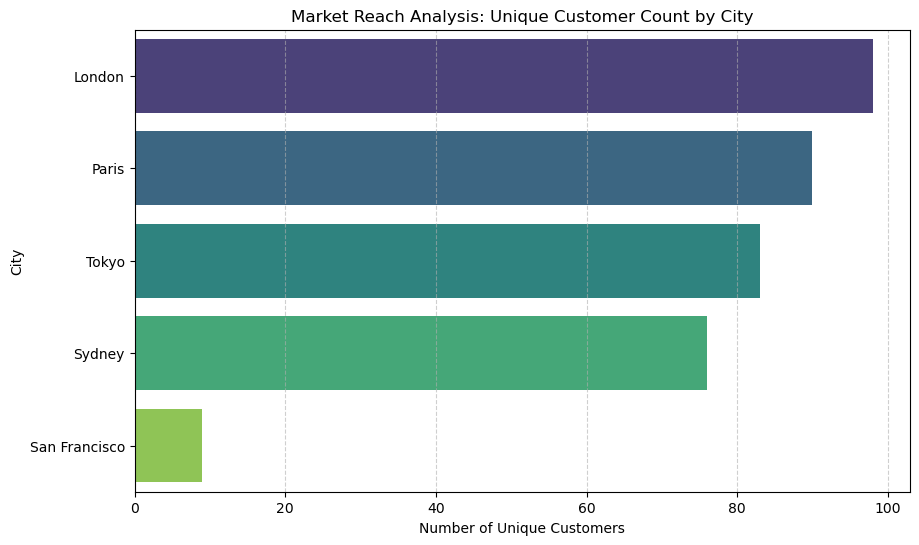

In [23]:
# Major cities to compare
major_cities = ['London', 'Tokyo', 'New York', 'Paris', 'San Francisco', 'Sydney']

# Filter and count unique customer
city_reach = df[df['City'].isin(major_cities)].groupby('City')['Customer ID'].nunique().sort_values(ascending=False).reset_index()
city_reach.columns = ['City', 'Unique_Customers']

# --- Visualization ---
plt.figure(figsize=(10, 6))
sns.barplot(data=city_reach, x='Unique_Customers', y='City', palette='viridis')
plt.title('Market Reach Analysis: Unique Customer Count by City')
plt.xlabel('Number of Unique Customers')
plt.ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

It looks like Tokyo has around the same customer count as other major cities in the world, so we don't think the Japanese market is new and doesn't need as big of a discount. We will compare Tokyo with another city from EMEA, because it seems like EMEA has biggest sales and profit while have profit margins close to the AMER region.

## **EMEA Cities and Industries Comparison**

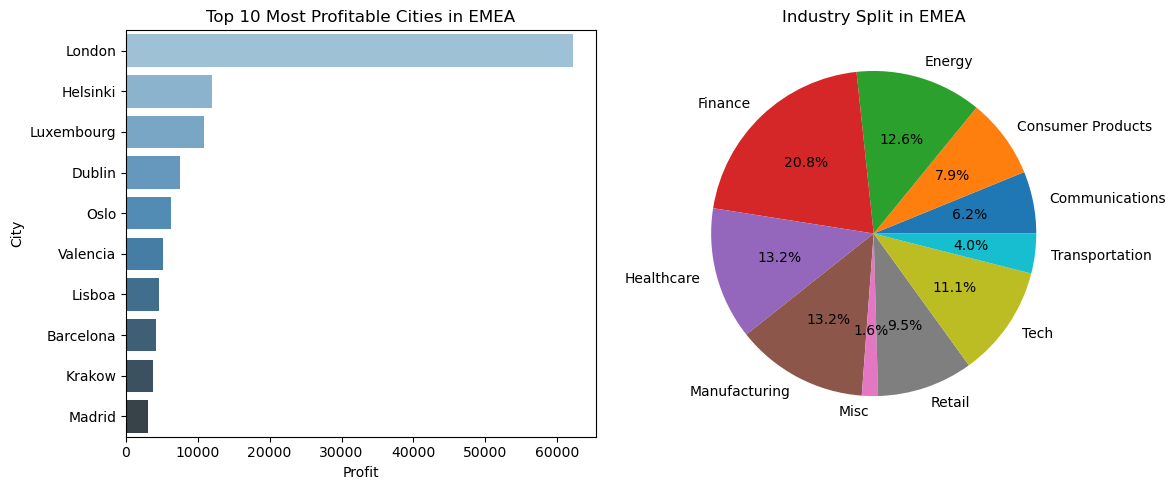

In [24]:
# EMEA filter
emea_df = df[df['Region'] == 'EMEA']

# EMEA sales based on subregion
emea_subregion = emea_df.groupby('Subregion')['Sales'].sum().sort_values(ascending=False).reset_index()

# Top 10 profitable EMEA cities
emea_city_profit = emea_df.groupby('City')['Profit'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 5))

# Most profitable city EMEA
plt.subplot(1, 2, 1)
sns.barplot(data=emea_city_profit, x='Profit', y='City', palette='Blues_d')
plt.title('Top 10 Most Profitable Cities in EMEA')

# Dominant industry EMEA
plt.subplot(1, 2, 2)
emea_industry = emea_df.groupby('Industry')['Sales'].sum().reset_index()
plt.pie(emea_industry['Sales'], labels=emea_industry['Industry'], autopct='%1.1f%%')
plt.title('Industry Split in EMEA')

plt.tight_layout()
plt.show()

It appears that London is the most profitable city found in EMEA with finance also being the biggest industry. We will see what makes London the most profitable city and compare it to Tokyo.

## **Hypothesis Testing**
Before we continue with our analysis, we can use hypothesis testing to see if there will be statistical differences between profits from London and Tokyo.

H0 : There is no statistical difference between profits in Tokyo and profits in London.

H1 : There is a statistical difference between profits in Tokyo and profits in London.

In [25]:
from scipy import stats

# Filter profit
london_profit = df[df['City'] == 'London']['Profit']
tokyo_profit = df[df['City'] == 'Tokyo']['Profit']

# T-Test
t_stat, p_val = stats.ttest_ind(london_profit, tokyo_profit, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.15f}")

if p_val < 0.05:
    print("Conclusion: Reject H0. There is a statistical difference between profits.")
else:
    print("Conclusion: Failed to reject H0. Profit difference might be a coincidence.")

T-Statistic: 7.7709
P-Value: 0.000000000000019
Conclusion: Reject H0. There is a statistical difference between profits.


From the hypothetical testing, is is shown that there is a statistical difference between profits from London and Tokyo.

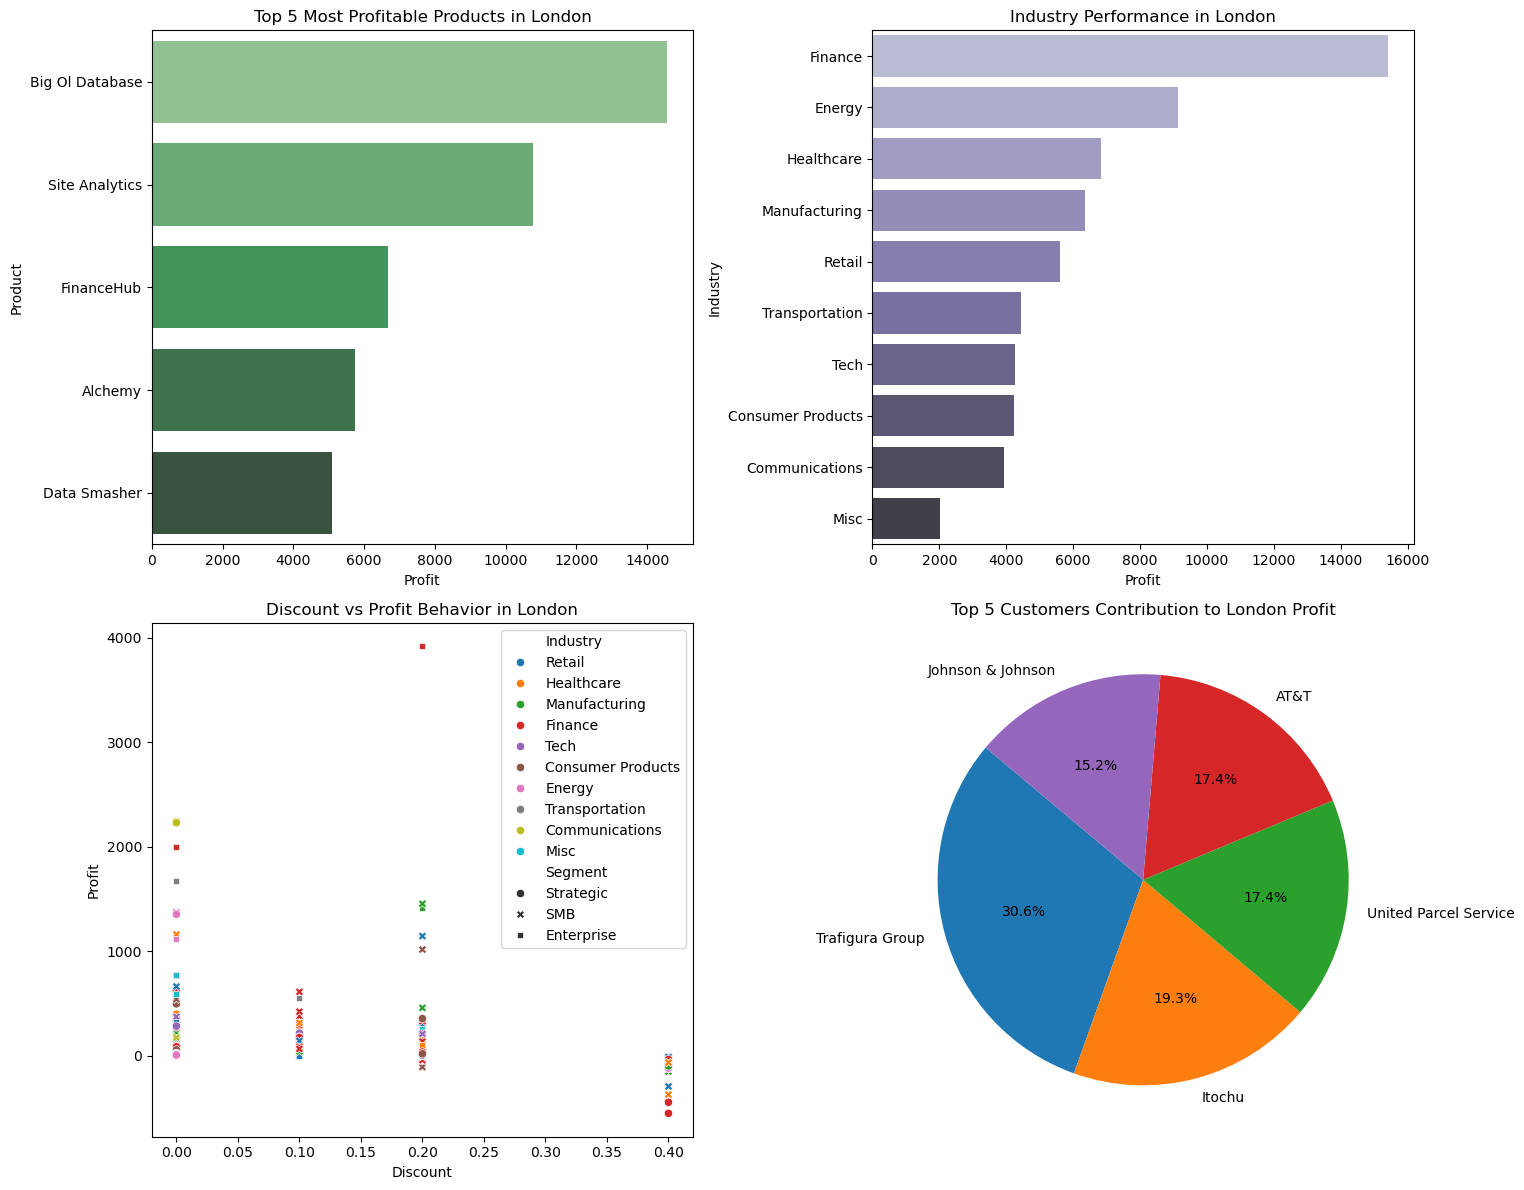

In [26]:
# London filter
london_df = df[df['City'] == 'London'].copy()

# Best products in London
london_products = london_df.groupby('Product').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values(by='Profit', ascending=False).reset_index()

# London industry analysis
london_industries = london_df.groupby('Industry').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Profit', ascending=False).reset_index()

# --- Visualization ---
plt.figure(figsize=(15, 12))

# London profit per product
plt.subplot(2, 2, 1)
sns.barplot(data=london_products.head(5), x='Profit', y='Product', palette='Greens_d')
plt.title('Top 5 Most Profitable Products in London')

# London profit per industry
plt.subplot(2, 2, 2)
sns.barplot(data=london_industries, x='Profit', y='Industry', palette='Purples_d')
plt.title('Industry Performance in London')

# Discount vs profit correlation
plt.subplot(2, 2, 3)
sns.scatterplot(data=london_df, x='Discount', y='Profit', hue='Industry', style='Segment')
plt.title('Discount vs Profit Behavior in London')

# Biggest customer contribution London
london_customers = london_df.groupby('Customer')['Profit'].sum().nlargest(5).reset_index()
plt.subplot(2, 2, 4)
plt.pie(london_customers['Profit'], labels=london_customers['Customer'], autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Customers Contribution to London Profit')

plt.tight_layout()
plt.show()

Finance is the biggest industry in London, it makes a lot of sense since like Tokyo, London is also the capital of its country. A big difference can be seen in London's discount behavior where discounts in London don't reach above 40% and not a lot of transactions receive that 40% discount.

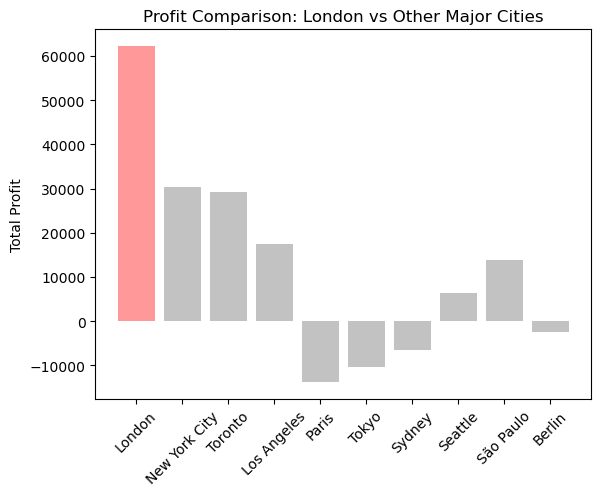

In [27]:
# Compare London to other major cities
top_cities = df.groupby('City').agg({'Sales':'sum', 'Profit':'sum'}).nlargest(10, 'Sales').reset_index()

colors = ['#FF9999' if city == 'London' else '#C2C2C2' for city in top_cities['City']]

plt.bar(top_cities['City'], top_cities['Profit'], color=colors)
plt.title('Profit Comparison: London vs Other Major Cities')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

Compared to other cities, London has the most profit. Whatever we're doing in London, we are doing a good job at it and we think what we're doing in London could be replicated in other major cities.

## **Tokyo and London Discount Comparison**

Korelasi Pearson: -0.2195
P-Value: 0.0000


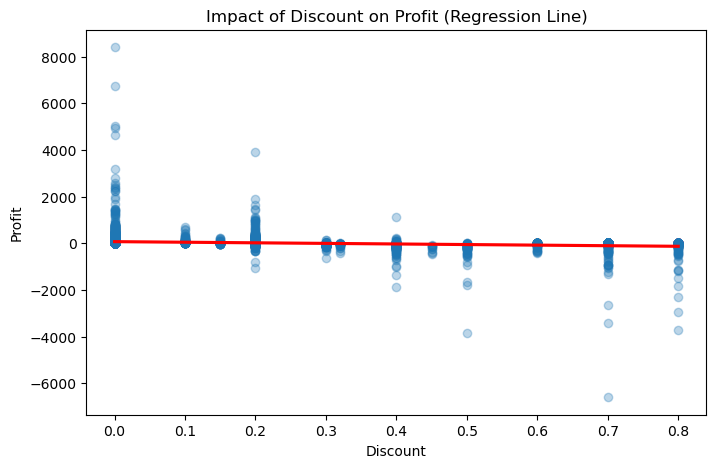

In [28]:
# Discount correlation to profit
correlation, p_value_corr = stats.pearsonr(df['Discount'], df['Profit'])

print(f"Korelasi Pearson: {correlation:.4f}")
print(f"P-Value: {p_value_corr:.4f}")

# Regression
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Discount', y='Profit', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impact of Discount on Profit (Regression Line)')
plt.show()

From the regression line, it seems that bigger discounts generally result in lower profits.

In [29]:
# Global metrics
global_avg_discount = df['Discount'].mean()
global_profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100

# London metrics
london_df = df[df['City'] == 'London']
london_avg_discount = london_df['Discount'].mean()
london_profit_margin = (london_df['Profit'].sum() / london_df['Sales'].sum()) * 100

# Tokyo metrics
tokyo_df = df[df['City'] == 'Tokyo']
tokyo_avg_discount = tokyo_df['Discount'].mean()
tokyo_profit_margin = (tokyo_df['Profit'].sum() / tokyo_df['Sales'].sum()) * 100

# Comparison
print(f"---- Efficiency Comparison ----")
print(f"Global Discount Average: {global_avg_discount:.2%}")
print(f"London Discount Average: {london_avg_discount:.2%}")
print(f"Tokyo Discount Average : {tokyo_avg_discount:.2%}")
print(f"-------------------------------")
print(f"GLobal Profit Margin   : {global_profit_margin:.2f}%")
print(f"London Profit Margn    : {london_profit_margin:.2f}%")
print(f"Tokyo Profit Margin    : {tokyo_profit_margin:.2f}%")

---- Efficiency Comparison ----
Global Discount Average: 15.62%
London Discount Average: 5.57%
Tokyo Discount Average : 37.37%
-------------------------------
GLobal Profit Margin   : 12.47%
London Profit Margn    : 24.12%
Tokyo Profit Margin    : -15.13%


--- Comparison Between London vs Tokyo ---
     City        Sales  ...  Profit Margin (%)  Sales per Customer
0  London  257944.1810  ...  24.120960          2632.083480       
1  Tokyo   68485.4264   ... -15.126633          825.125619        

[2 rows x 8 columns]


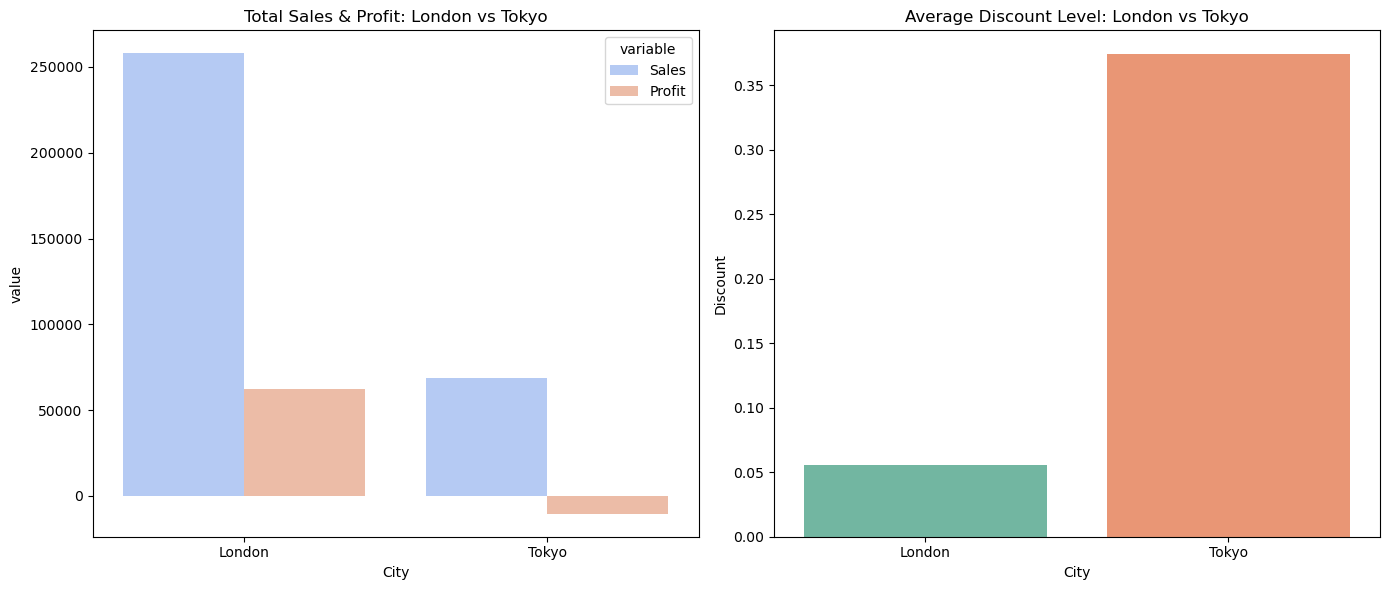

In [30]:
# London and Tokyo filter
comparison_cities = df[df['City'].isin(['London', 'Tokyo'])].copy()

# Comparison metrics
city_stats = comparison_cities.groupby('City').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean',
    'Quantity': 'sum',
    'Customer ID': 'nunique'
}).reset_index()

# Profit Margin and Average Order Value (AOV)
city_stats['Profit Margin (%)'] = (city_stats['Profit'] / city_stats['Sales']) * 100
city_stats['Sales per Customer'] = city_stats['Sales'] / city_stats['Customer ID']

print("--- Comparison Between London vs Tokyo ---")
print(city_stats)

# --- Visualization ---
plt.figure(figsize=(14, 6))

# Sales vs Profit
plt.subplot(1, 2, 1)
city_stats_melted = city_stats.melt(id_vars='City', value_vars=['Sales', 'Profit'])
sns.barplot(data=city_stats_melted, x='City', y='value', hue='variable', palette='coolwarm')
plt.title('Total Sales & Profit: London vs Tokyo')

# Discount comparison
plt.subplot(1, 2, 2)
sns.barplot(data=city_stats, x='City', y='Discount', palette='Set2')
plt.title('Average Discount Level: London vs Tokyo')

plt.tight_layout()
plt.show()

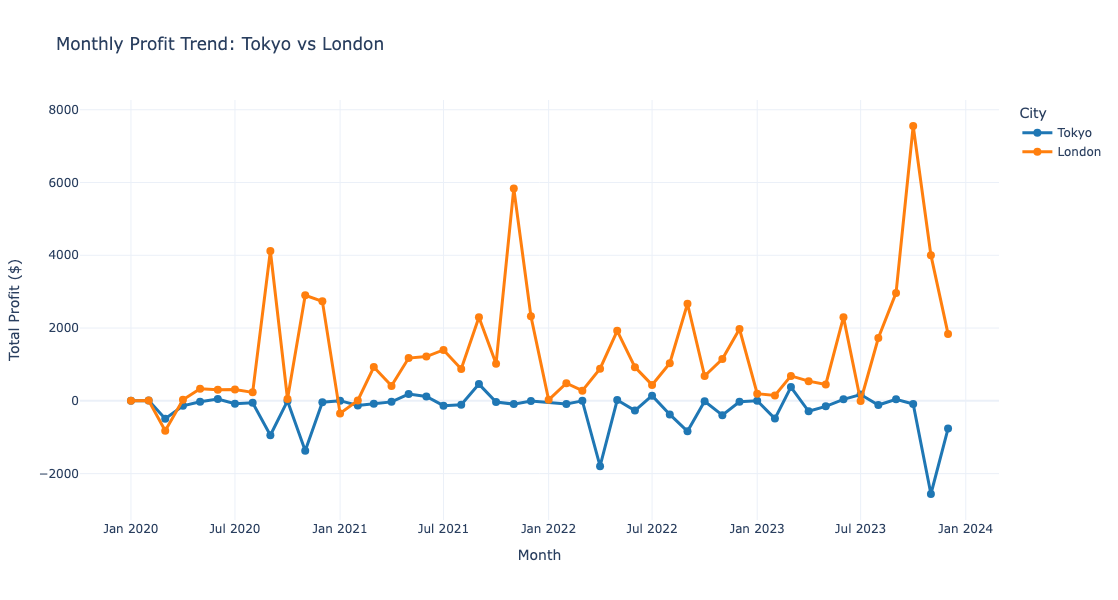

In [31]:
# Filter data for Tokyo and London
df_comparison = df[df['City'].isin(['Tokyo', 'London'])].copy()

# Aggregate monthly profit
df_trend = df_comparison.groupby(['City', pd.Grouper(key='Order Date', freq='MS')])['Profit'].sum().reset_index()

fig = go.Figure()

# Tokyo trend line
fig.add_trace(go.Scatter(
    x=df_trend[df_trend['City'] == 'Tokyo']['Order Date'],
    y=df_trend[df_trend['City'] == 'Tokyo']['Profit'],
    mode='lines+markers',
    name='Tokyo',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=8)
))

# London trend line
fig.add_trace(go.Scatter(
    x=df_trend[df_trend['City'] == 'London']['Order Date'],
    y=df_trend[df_trend['City'] == 'London']['Profit'],
    mode='lines+markers',
    name='London',
    line=dict(color='#ff7f0e', width=3),
    marker=dict(size=8)
))

fig.update_layout(
    title='Monthly Profit Trend: Tokyo vs London',
    xaxis_title='Month',
    yaxis_title='Total Profit ($)',
    legend_title='City',
    template='plotly_white',
    hovermode='x unified',
    height = 600
)

fig.show()

When comparing profit trends between Tokyo and London, there appears to be a pattern of profit spiking around the end of the year for London and Tokyo. That could be because companies renew their license at that time. Or it could be when AWS give out discounts to their customers.

     City       Sales  Discount     Profit
0  London  316.625028  0.063889  71.338918
1  Tokyo   182.388257  0.348085 -54.736201


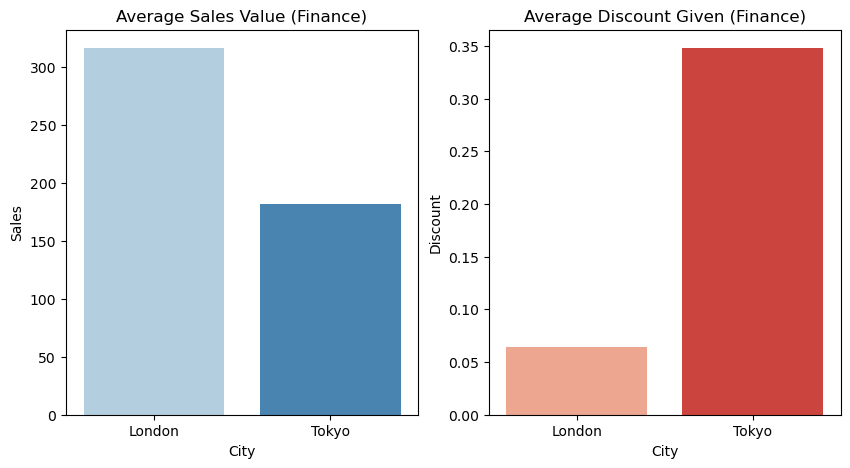

In [32]:
# London and Tokyo finance filter
finance_comp = df[(df['Industry'] == 'Finance') & (df['City'].isin(['London', 'Tokyo']))].copy()

# Comparison metric
finance_stats = finance_comp.groupby('City').agg({
    'Sales': 'mean',      # Rata-rata nilai transaksi
    'Discount': 'mean',   # Rata-rata diskon
    'Profit': 'mean'      # Rata-rata profit per transaksi
}).reset_index()

print(finance_stats)

# Sales and discount comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=finance_stats, x='City', y='Sales', palette='Blues')
plt.title('Average Sales Value (Finance)')

plt.subplot(1, 2, 2)
sns.barplot(data=finance_stats, x='City', y='Discount', palette='Reds')
plt.title('Average Discount Given (Finance)')
plt.show()

We can see that London has almost 3x sales for every customer compared to Tokyo. Discounts could be a big factor when we see that London has an average discount of 5.57% while Tokyo has an average of 37.37% which is 6.7x more than London while the global discount is only 15.62%, which is only around half of Tokyo's average. 

A city's segment might also contribute to its profit. It could be that customers from Japan are from smaller businesses which could explain lower prices while customers from London are mostly huge enterprises who can spend more on software compared to the smaller businesses.

## **Tokyo and London Comparison by Segment**

     City     Segment  ...  Transaction_Count  Profit_Margin_%
0  London  Enterprise  ...  145                30.889015      
1  London  SMB         ...  508                22.232234      
2  London  Strategic   ...  269                22.254338      
3  Tokyo   Enterprise  ...  78                -9.273914       
4  Tokyo   SMB         ...  224               -24.300894      
5  Tokyo   Strategic   ...  103               -4.037280       

[6 rows x 7 columns]


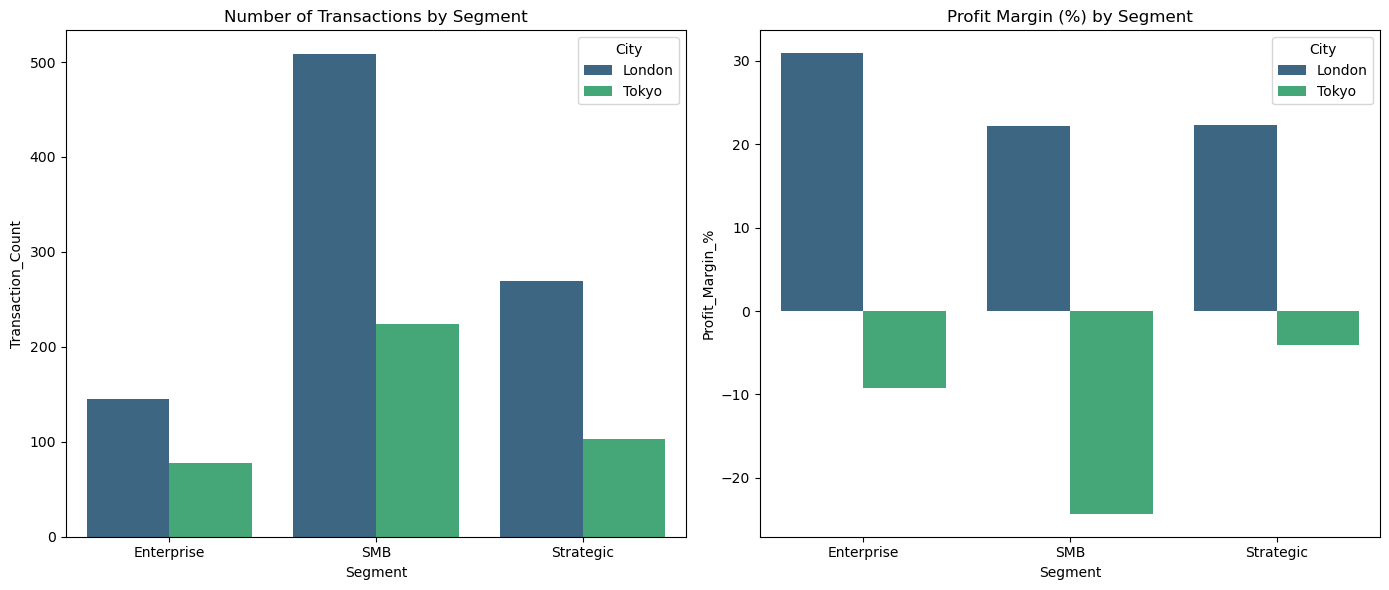

In [33]:
# London and Tokyo filter
city_comp = df[df['City'].isin(['London', 'Tokyo'])].copy()

# Profit Margin per Segment
segment_stats = city_comp.groupby(['City', 'Segment']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean',
    'Row ID': 'count'
}).reset_index()
segment_stats.rename(columns={'Row ID': 'Transaction_Count'}, inplace=True)
segment_stats['Profit_Margin_%'] = (segment_stats['Profit'] / segment_stats['Sales']) * 100

print(segment_stats)

# --- Visualization ---
plt.figure(figsize=(14, 6))

# Transaction composition
plt.subplot(1, 2, 1)
sns.barplot(data=segment_stats, x='Segment', y='Transaction_Count', hue='City', palette='viridis')
plt.title('Number of Transactions by Segment')

# Profit margin
plt.subplot(1, 2, 2)
sns.barplot(data=segment_stats, x='Segment', y='Profit_Margin_%', hue='City', palette='viridis')
plt.title('Profit Margin (%) by Segment')

plt.tight_layout()
plt.show()

--- SMB Performance Comparison ---
     City       Sales     Profit  Discount  Quantity
0  London  271.733352  60.412394  0.057283  3.767717
1  Tokyo   155.388646 -37.760830  0.387411  3.741071


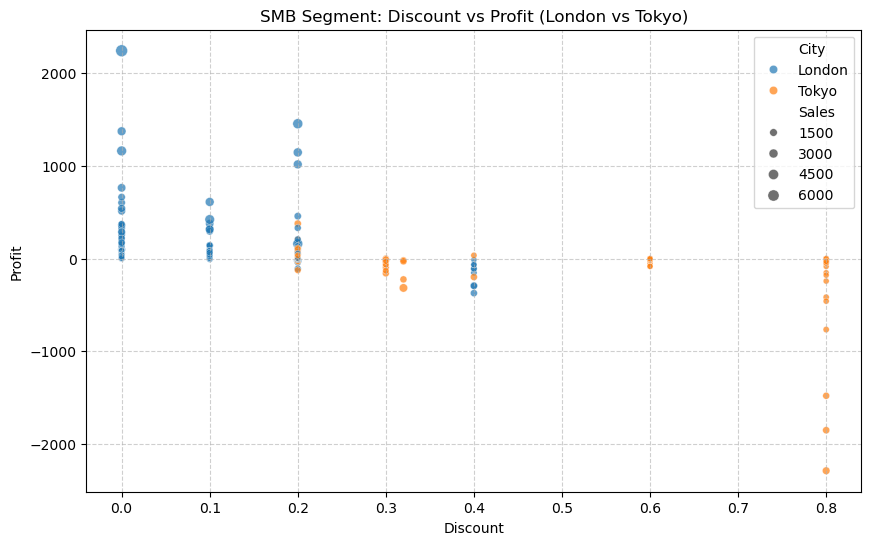

In [34]:
# London and Tokyo SMB segment filter
smb_comp = df[(df['Segment'] == 'SMB') & (df['City'].isin(['London', 'Tokyo']))].copy()

# Descriptive statistics
smb_stats = smb_comp.groupby('City').agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Discount': 'mean',
    'Quantity': 'mean'
}).reset_index()

print("--- SMB Performance Comparison ---")
print(smb_stats)

# Discount vs Profit scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=smb_comp, x='Discount', y='Profit', hue='City', size='Sales', alpha=0.7)
plt.title('SMB Segment: Discount vs Profit (London vs Tokyo)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

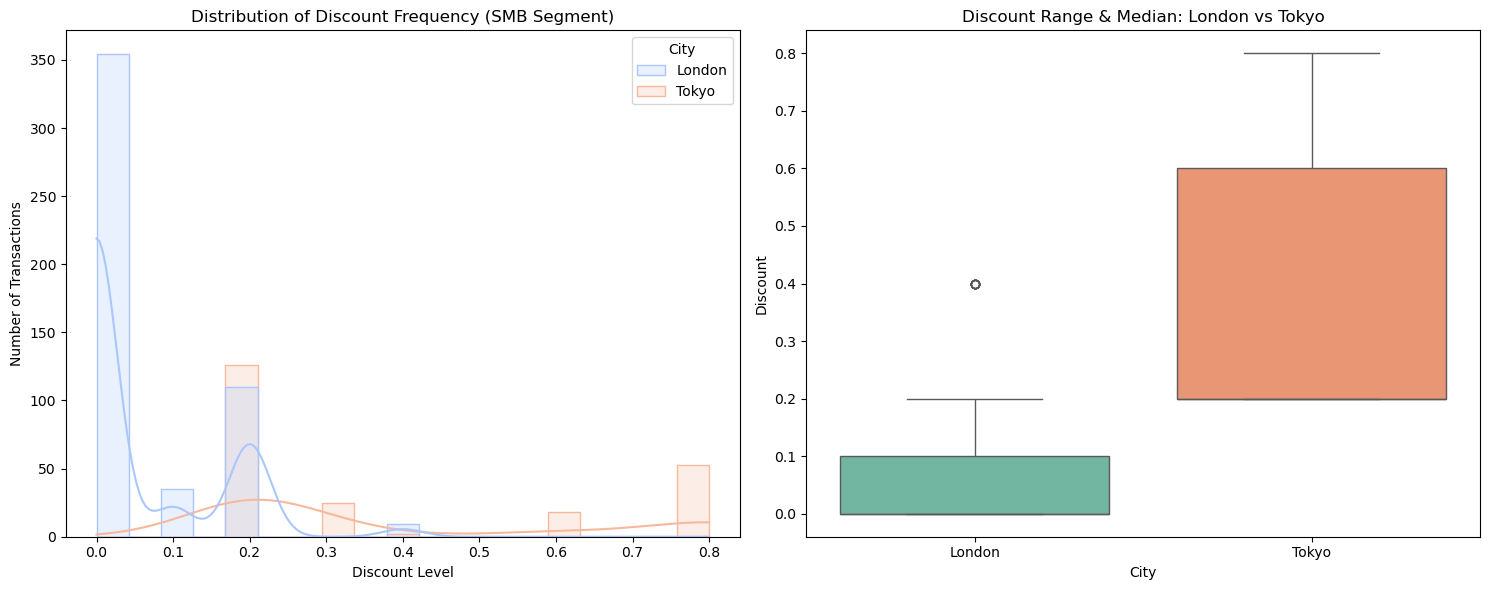

In [35]:
# London and Tokyo SMB segment
smb_compare = df[(df['Segment'] == 'SMB') & (df['City'].isin(['London', 'Tokyo']))].copy()

# Discount distribution
plt.figure(figsize=(15, 6))

# Discount frequency
plt.subplot(1, 2, 1)
sns.histplot(data=smb_compare, x='Discount', hue='City', element='step', kde=True, palette='coolwarm')
plt.title('Distribution of Discount Frequency (SMB Segment)')
plt.xlabel('Discount Level')
plt.ylabel('Number of Transactions')

# Discount box plot
plt.subplot(1, 2, 2)
sns.boxplot(data=smb_compare, x='City', y='Discount', palette='Set2')
plt.title('Discount Range & Median: London vs Tokyo')

plt.tight_layout()
plt.show()

Just like Tokyo, it turns out that transactions in London are mostly made from small businesess (SMB) and if we see the discounts from each city's small businesses, Tokyo has a minimum discount of 20% with a majority being 20% and above and reaching 80% while London's small businesses mostly gets given a 20% or less discount with only a minority getting a 40%.

## **Top 5 and Bottom 5 Finance SMB Customers in London and Tokyo**

In [36]:
# --- LONDON ---
# Filter: London + Finance + SMB
london_finance_smb = df[(df['City'] == 'London') & 
                        (df['Industry'] == 'Finance') & 
                        (df['Segment'] == 'SMB')]

# Top 5 and bottom 5 London
top_5_london = london_finance_smb['Customer'].value_counts().nlargest(5)
bot_5_london = london_finance_smb['Customer'].value_counts().nsmallest(5)

# --- TOKYO ---
# Filter: Tokyo + Finance + SMB
tokyo_finance_smb = df[(df['City'] == 'Tokyo') & 
                       (df['Industry'] == 'Finance') & 
                       (df['Segment'] == 'SMB')]

# Top 5 and bottom 5 Tokyo
top_5_tokyo = tokyo_finance_smb['Customer'].value_counts().nlargest(5)
bot_5_tokyo = tokyo_finance_smb['Customer'].value_counts().nsmallest(5)

print("Top 5 Finance SMB Customers in London:\n", top_5_london)
print("\nBottom 5 Finance SMB Customers in London:\n", bot_5_london)
print("\nTop 5 Finance SMB Customers in Tokyo:\n", top_5_tokyo)
print("\nBottom 5 Finance SMB Customers in Tokyo:\n", bot_5_tokyo)

Top 5 Finance SMB Customers in London:
 Customer
Wells Fargo              17
Goldman Sachs Group      16
Morgan Stanley           11
Bank of America Corp.    10
Itochu                   10
Name: count, dtype: int64

Bottom 5 Finance SMB Customers in London:
 Customer
Fannie Mae                   2
General Electric             3
State Farm Insurance Cos.    3
BNP Paribas                  5
J.P. Morgan Chase & Co.      6
Name: count, dtype: int64

Top 5 Finance SMB Customers in Tokyo:
 Customer
Fannie Mae                 7
Morgan Stanley             7
Wells Fargo                6
J.P. Morgan Chase & Co.    6
Prudential Financial       6
Name: count, dtype: int64

Bottom 5 Finance SMB Customers in Tokyo:
 Customer
Goldman Sachs Group    1
Berkshire Hathaway     1
Aviva                  1
American Express       1
BNP Paribas            3
Name: count, dtype: int64


To increase profits, we think we should decrease discount amounts to the top 5 customers and give more discounts to the bottom 5 because getting new customers is harder than retain older customers and giving smaller discounts to returning buyers who'd likely buy again could increase profits.

## **Cost vs Volume**

--- COST VS VOLUME (SMB FINANCE) ---
     City  Row ID  Quantity  ...     Profit  Cost_per_Sale  Profit_Margin_%
0  London  137     550       ...  7005.1901  0.076220       20.420280      
1  Tokyo   52      209       ... -5051.0072  0.390712      -40.320641      

[2 rows x 8 columns]


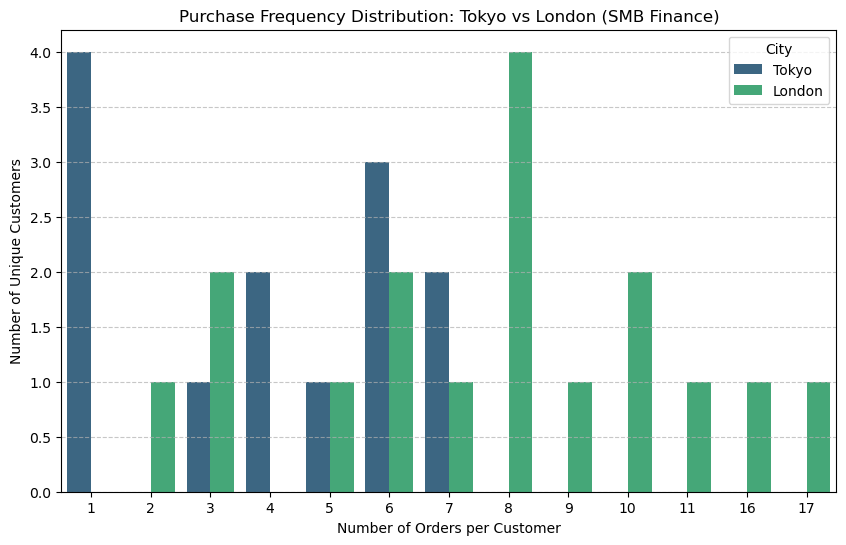

In [37]:

# Filter: Segment SMB + Industry Finance + City (Tokyo & London)
mask = (df['Segment'] == 'SMB') & \
       (df['Industry'] == 'Finance') & \
       (df['City'].isin(['Tokyo', 'London']))
df_filtered = df[mask].copy()

# 'Cost of Sales' 
df_filtered['Discount_Value'] = df_filtered['Sales'] * df_filtered['Discount']

# 4. Aggregation between cities: Cost vs Volume
cost_volume_table = df_filtered.groupby('City').agg({
    'Row ID': 'count',           # Volume Transaksi
    'Quantity': 'sum',           # Volume Unit
    'Sales': 'sum',              # Total Revenue
    'Discount_Value': 'sum',     # Total 'Cost' dari diskon
    'Profit': 'sum'              # Hasil Akhir
}).reset_index()

# Efficiency metric
cost_volume_table['Cost_per_Sale'] = cost_volume_table['Discount_Value'] / cost_volume_table['Sales']
cost_volume_table['Profit_Margin_%'] = (cost_volume_table['Profit'] / cost_volume_table['Sales']) * 100

print("--- COST VS VOLUME (SMB FINANCE) ---")
print(cost_volume_table)

# Viz
# Customer frequency
customer_freq = df_filtered.groupby(['City', 'Customer ID']).size().reset_index(name='Frequency')

plt.figure(figsize=(10, 6))
sns.countplot(data=customer_freq, x='Frequency', hue='City', palette='viridis')

plt.title('Purchase Frequency Distribution: Tokyo vs London (SMB Finance)')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Unique Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

This shows that a lot of customer from Tokyo are first-time buyer while customers from London are repeat buyers. Tokyo has a retention issue that needs to be tended to. The subsidized cost from Tokyo is also higher than it is in London which means customer acquisition in Tokyo costs more than London. Tokyo has a retention issue that needs to be tended to.

## **Conclusion**
From the analysis above, it turns out that APJ has the lowest sales, profit, and profit margin. Looking deeper into APJ, we found out that Tokyo has the lowest sales with finance being the dominant industry. Being Japan's capital, it doesn't feel right that Tokyo has the lowest profit out of the whole APJ region, so we compared it with other cities across regions. Turns out that compared to other major cities, Tokyo really has the lowest profit among them all.

After comparing with London, the most profitable city out of all the major cities. Turns out London also has the same parameters with Tokyo being SMD dominant and finance being the most dominant industry. We found that compared to the global average, Tokyo gives out more discounts overall while London gives less discounts than the global average. Seeing the customer cost between both cities, it costs more to acquire a customer in Tokyo than it is in London while customer retention in Tokyo needs to be looked into. Although not the only reasons, the discounts given in Tokyo needs to be revamped in some way.

## **Recommendations**
1. **Discount adjustment**: Adjust discounts given on purchases from Tokyo where 80% discounts are significantly lower than the current amount. Give the bigger discounts for newer customers so they can keep buying from AWS. Give lower discount amounts and give a more personalized approach to returning customers so we can still retain them

2. **Increase Operational Costs**: Since AWS sells software and software needs maintenance, to increase profits, operational costs could be increased or create an automation process for a lighter load on overall cost and streamline the maintenance process.

3. **Know your customers**: Analyze repeat customers like Fannie Mae, Morgan Stanley, and Wells Fargo for better insights on what they need and how they work.

4. **Don't fix whats not broken**: Try to perform the same strategy used on other cities that have been proven successful.